In [10]:
import pandas as pd
import numpy as np


In [11]:
city = "北京"

In [12]:
housing = pd.read_csv(f'processed_data/{city}/01_housing.csv')

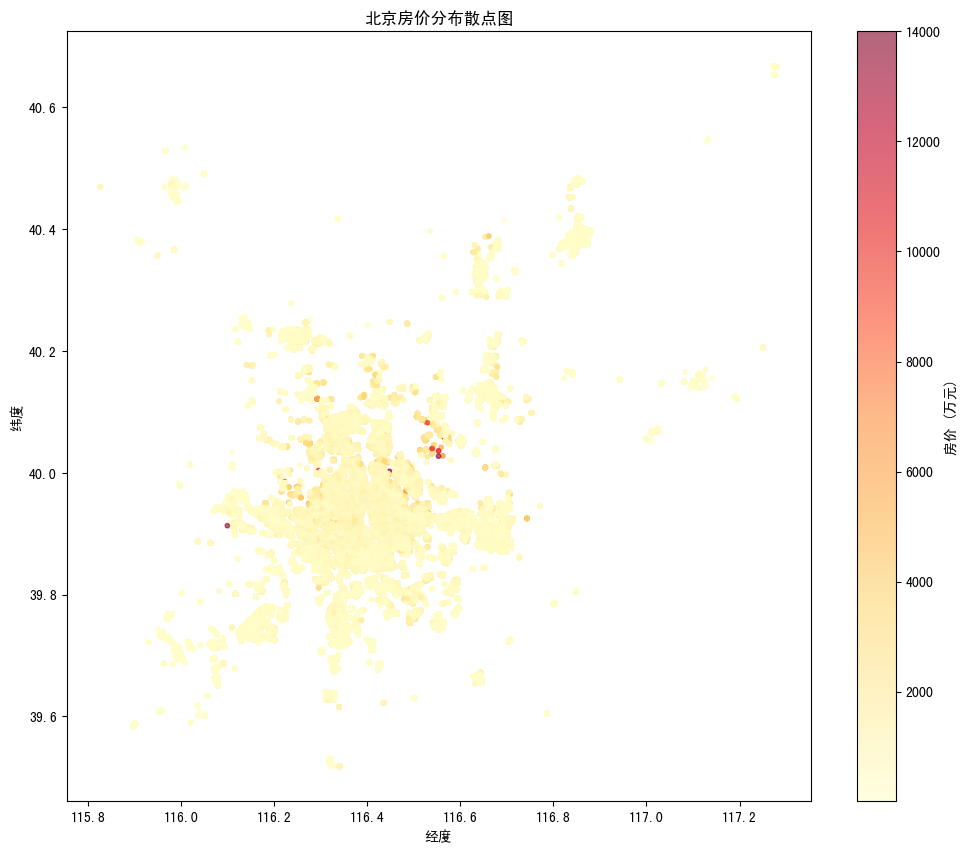

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
# support chinese characters
plt.rcParams['font.sans-serif'] = ['SimHei']
df = housing

plt.figure(figsize=(12, 10))
scatter = plt.scatter(df['x'], df['y'], c=df['price'], 
                      cmap='YlOrRd', s=10, alpha=0.6)
plt.colorbar(scatter, label='房价 (万元)')
plt.title('北京房价分布散点图')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.show()

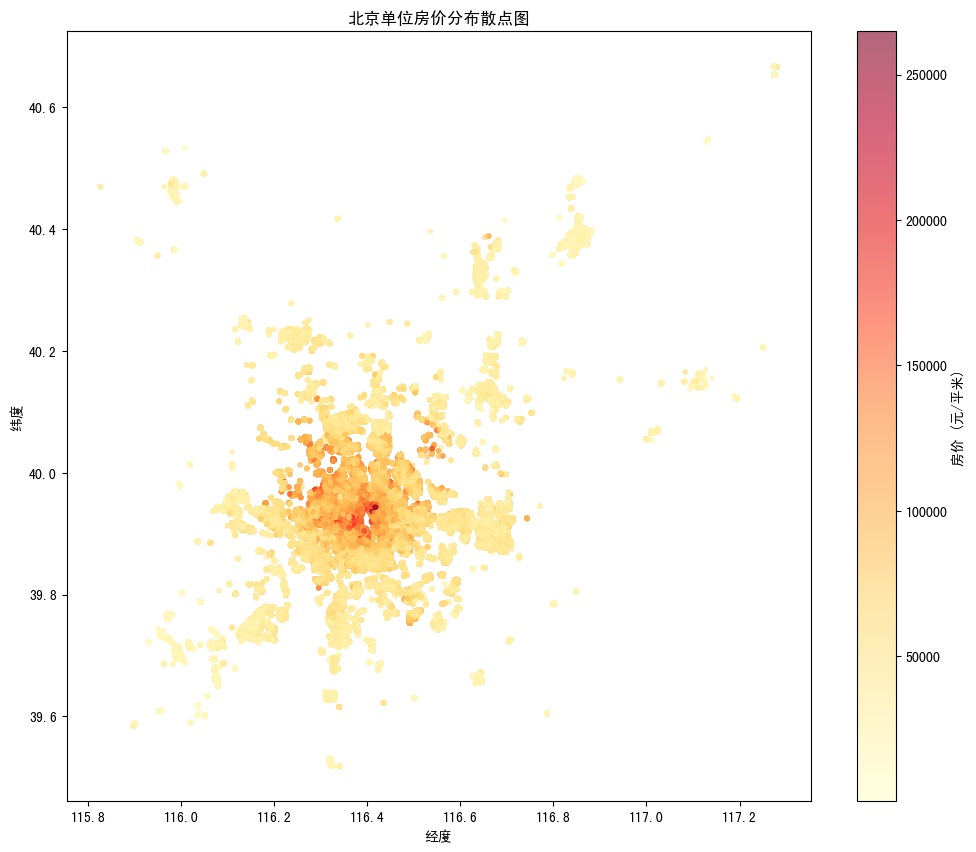

In [14]:
plt.rcParams['font.sans-serif'] = ['SimHei']
df = housing

plt.figure(figsize=(12, 10))
scatter = plt.scatter(df['x'], df['y'], c=df['unit_price'], 
                      cmap='YlOrRd', s=10, alpha=0.6)
plt.colorbar(scatter, label='房价 (元/平米)')
plt.title('北京单位房价分布散点图')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.show()

In [15]:
def calculate_center(df):

    center_lat = df['y'].mean()
    center_lng = df['x'].mean()
    
    return center_lat, center_lng

In [16]:
from utils import haversine_np

center_lat, center_lng = calculate_center(housing)
housing['distance_to_center'] = housing.apply(lambda row: haversine_np(row['x'], row['y'], center_lng, center_lat), axis=1)

In [17]:
housing['distance_to_center']

0          3.022736
1         21.951697
2         22.192751
3         17.126073
4          8.180078
            ...    
261154    26.530575
261155     8.324624
261156    68.561531
261157    65.728248
261158    59.853058
Name: distance_to_center, Length: 261159, dtype: float64

In [18]:
housing.to_csv(f'processed_data/{city}/02_data.csv', index=False)